# Bayesian Estimation of a Sticky-Wage HANK Model
## PS4 — Advanced Topics in Monetary Economics with Heterogeneous Agents

This notebook estimates a HANK model with sticky wages and three aggregate shocks
(monetary, TFP, government spending) using the SSJ framework.

**Two computational engines:**
- **`sequence_jacobian`** v1.0 (shade-econ): DAG composition, GE Jacobians, estimation
- **`hetmacro`** (our package): EGM, Rouwenhorst, grids — verified side-by-side

See Macro Bible Appendix A.3 (`subsec:ssj_estimation`) for the theory.

In [1]:
# General python packages
import sys, copy, time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.optimize as opt

# sequence_jacobian v1.0 (shade-econ)
import sequence_jacobian as sj
from sequence_jacobian import simple, het, solved
import sequence_jacobian.utilities as sj_utils
from sequence_jacobian import estimation as ssj_est

# hetmacro (our package)
sys.path.insert(0, '../../')
import hetmacro
from hetmacro.markov import rouwenhorst as hm_rouwenhorst
from hetmacro.grids import make_asset_grid as hm_make_asset_grid
from hetmacro.backward import backward_egm as hm_backward_egm

# Plot formatting
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['axes.xmargin'] = 0
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=10)

print("Imports OK")

Imports OK


---
## 1. Data Preparation

US quarterly data: inflation, log real GDP (detrended), nominal interest rate, 1966Q1-2004Q4.

In [2]:
try:
    import pandas_datareader.data as web
    from datetime import datetime
    start, end = datetime(1966, 1, 1), datetime(2004, 12, 31)

    gdp_defl = web.DataReader('GDPDEF', 'fred', start, end).resample('QS').first()
    pi_data = gdp_defl.pct_change().dropna().values.flatten()

    rgdp = web.DataReader('GDPC1', 'fred', start, end).resample('QS').first()
    log_gdp = np.log(rgdp.values.flatten())
    t_trend = np.arange(len(log_gdp))
    slope, intercept = np.polyfit(t_trend, log_gdp, 1)
    y_data = (log_gdp - (slope * t_trend + intercept))

    ffr = web.DataReader('FEDFUNDS', 'fred', start, end).resample('QS').mean().values.flatten() / 400

    n = min(len(pi_data), len(y_data) - 1, len(ffr))
    data_real = np.column_stack([pi_data[:n] - np.mean(pi_data[:n]),
                                  y_data[1:n+1] - np.mean(y_data[1:n+1]),
                                  ffr[:n] - np.mean(ffr[:n])])
    USE_REAL_DATA = True
    print(f"Real data loaded: {data_real.shape}")
except Exception as e:
    print(f"FRED data unavailable ({e}). Using simulated data only.")
    USE_REAL_DATA = False

Real data loaded: (155, 3)


---
## 2. Model Definition: Sticky-Wage HANK

**Household**: CRRA utility, Rouwenhorst income, borrowing constraint, EGM solution
**Wage Phillips curve**: $\pi_t^w = \kappa_w(MRS - w/\mu) + \beta \pi_{t+1}^w$
**Taylor rule**: $i_t = r_{ss} + \phi_\pi \pi_t + \varepsilon_t$, Fisher: $r_t = i_t - \pi_{t+1}$
**Fiscal**: $T_t = T_{ss} + \phi_T(B_{t-1} - \bar{B})$, $B_t = (1+r_{t-1})B_{t-1} + G_t - T_t$
**Clearing**: $C + G = Y$ (goods), $A = B$ (assets)
**Shocks**: $\varepsilon_t, X_t, G_t$ all AR(1)

**DAG**: exogenous $\mathcal{Z}=\{\varepsilon, X, G\}$, unknowns $\mathcal{U}=\{Y, \pi\}$, targets $\mathcal{H}=\{$asset_mkt, piwres$\}$

In [3]:
# --- Grid construction ---
@simple
def construct_grids(amax, amin, rho_e, sd_e, nA, nS):
    a_grid = sj_utils.discretize.agrid(amax=amax, n=nA, amin=amin)
    e_grid, e_pdf, Pi = sj_utils.discretize.markov_rouwenhorst(rho=rho_e, sigma=sd_e, N=nS)
    return a_grid, e_grid, e_pdf, Pi

In [4]:
# --- Household HA block ---
def income_incidence(e_grid, Y, T):
    y_grid = (Y - T) * e_grid
    return y_grid

def household_init(rpost, Y, T, sigma, a_grid, e_grid):
    coh = (1 + rpost) * a_grid[np.newaxis, :] + (Y - T) * e_grid[:, np.newaxis]
    Va = (1 + rpost) * (0.2 * coh) ** (-sigma)
    return Va

@het(exogenous='Pi', policy='a', backward='Va', backward_init=household_init,
     hetinputs=[income_incidence])
def household(Va_p, a_grid, acons, e_grid, y_grid, rpost, beta, sigma):
    """Single backward EGM step with CRRA utility.

    Note: Va_p already includes the expectation E[Va'|e] = Pi @ Va,
    applied automatically by the @het decorator.
    """
    uc_nextgrid = beta * Va_p
    c_nextgrid = uc_nextgrid ** (-1 / sigma)
    lhs = c_nextgrid + a_grid[np.newaxis, :] - y_grid[:, np.newaxis]
    rhs = (1 + rpost) * a_grid
    a = sj.interpolate.interpolate_y(lhs, rhs, a_grid)
    sj.misc.setmin(a, acons)
    c = rhs[np.newaxis, :] + y_grid[:, np.newaxis] - a
    uc = c ** (-sigma)
    Va = (1 + rpost) * uc
    uce = uc * e_grid[:, np.newaxis]
    return Va, a, c, uc, uce

In [5]:
# --- Household RA block ---
@solved(unknowns={'C': 1., 'A': 1.}, targets=['Cres', 'Ares'], solver="broyden_custom")
def household_ra(C, A, r, rpost, Y, T, beta, sigma):
    Cres = beta * (1 + r) * C(1)**(-sigma) - C**(-sigma)
    Ares = (1 + rpost) * A(-1) + Y - T - C - A
    return Cres, Ares

In [6]:
# --- Aggregate blocks ---
@simple
def rpost_simple(r):
    rpost = r(-1)
    return rpost

@simple
def monetary_taylor(pi, ishock, rss, phi_pi):
    i = rss + phi_pi * pi + ishock
    r = i - pi(1)
    return i, r

@simple
def nkpc(pi, Y, X, C, kappa_w, vphi, frisch, markup_ss, eis, beta):
    piw = pi + X - X(-1)
    N = Y / X
    piwres = kappa_w * (vphi * N**(1/frisch) - 1/markup_ss * X * C**(-1/eis)) + beta * piw(1) - piw
    return piwres, piw, N

@simple
def mkt_clearing(A, B, Y, C, G):
    asset_mkt = A - B
    goods_mkt = C + G - Y
    return asset_mkt, goods_mkt

@solved(unknowns={'B': 0}, targets=['Bres'], solver="brentq")
def fiscal_TBrule(r, G, B, Tss, phi_T):
    T = Tss + phi_T * (B(-1) - B.ss)
    Bres = (1 + r(-1)) * B(-1) + G - T - B
    return T, Bres

In [7]:
# --- DAG setup ---
blocks_ha = [household, mkt_clearing, nkpc, rpost_simple, monetary_taylor, fiscal_TBrule]
blocks_ra = [household_ra, mkt_clearing, nkpc, rpost_simple, monetary_taylor, fiscal_TBrule]

exogenous = ['ishock', 'X', 'G']
unknowns = ['Y', 'pi']
targets = ['asset_mkt', 'piwres']

# Create model objects (v1.0 API)
model_ha = sj.create_model(blocks_ha)
model_ra = sj.create_model(blocks_ra)
print("Models created")

Models created


In [8]:
# Visualize DAG
sj.drawdag(blocks_ha + [construct_grids])

/opt/anaconda3/lib/python3.12/site-packages/sequence_jacobian/utilities/drawdag.py:98: UserWarning: 
Attempted to use `drawdag` when the package `graphviz` has not yet been installed. 
DAG visualization tools, i.e. drawdag, will not produce any figures unless this dependency has been installed. 
If you want to install, try typing 'conda install -c conda-forge python-graphviz' at the terminal,
or see README for more instructions. Once installed, re-load sequence-jacobian to produce DAG figures.


---
## 3. Steady State Calibration

In [9]:
from sequence_jacobian.classes.steady_state_dict import SteadyStateDict

def build_calibration(model='ha', amin=-1, phi_T=0.1, B=0, G=0,
                     beta_min=0.75, beta_max=0.85, nA=500, kappa_w=0.2, phi_pi=1.5):
    """Build calibration dict and compute steady state."""

    calib = {"sigma": 2, "r": 0.01, "rho_e": 0.92, "sd_e": 0.92,
             "Y": 1, 'N': 1, 'X': 1, 'G': G, 'B': B, 'phi_T': phi_T,
             'kappa_w': kappa_w, 'frisch': 0.5, 'markup_ss': 1.015, 'phi_pi': phi_pi,
             "nS": 11, "amax": 1000, "amin": amin, "nA": nA, 'acons': amin}

    calib['w'] = calib['X']
    calib['rss'] = calib['r']
    calib['rpost'] = calib['r']
    calib['T'] = calib['r'] * calib['B'] + calib['G']
    calib.update({'Tss': calib['T'], 'Gss': calib['G']})
    calib['eis'] = 1 / calib['sigma']

    if model == 'ha':
        ha_model = sj.create_model([household, mkt_clearing, construct_grids])
        ss = ha_model.solve_steady_state(
            calib, {"beta": (beta_min, beta_max)}, ["asset_mkt"],
            solver="brentq"
        )
        # Add nominal side, preserving het block internals
        ss_dict = dict(ss)
        ss_dict.update({'pi': 0, 'piw': 0, 'ishock': 0})
        ss_dict['i'] = ss_dict['r'] + ss_dict['pi']
        ss_dict['vphi'] = (ss_dict['Y'] / ss_dict['N'] * 1 / ss_dict['markup_ss']
                           * ss_dict['C']**(-1/ss_dict['eis']) * ss_dict['N']**(-1/ss_dict['frisch']))
        ss_out = SteadyStateDict(ss_dict, internals=ss.internals)
    else:
        calib['beta'] = 1 / (1 + calib['r'])
        calib['A'] = calib['B']
        calib['C'] = calib['Y'] - calib['G']
        calib.update({'pi': 0, 'piw': 0, 'ishock': 0, 'i': calib['r']})
        calib['vphi'] = (calib['Y'] / calib['N'] * 1 / calib['markup_ss']
                         * calib['C']**(-1/calib['eis']) * calib['N']**(-1/calib['frisch']))
        ss_out = SteadyStateDict(calib)

    print(f"  {model.upper()}: beta={ss_out['beta']:.6f}, C={ss_out['C']:.4f}, A={ss_out['A']:.4f}")
    print(f"  Walras: {ss_out['Y'] - ss_out['C'] - ss_out['G']:.2e}")
    return ss_out

In [10]:
print("Calibrating steady states...")
ss_ha = build_calibration(model='ha')
ss_ra = build_calibration(model='ra')

Calibrating steady states...


  HA: beta=0.823352, C=1.0000, A=0.0000
  Walras: -1.18e-10
  RA: beta=0.990099, C=1.0000, A=0.0000
  Walras: 0.00e+00


---
## 2b. hetmacro Side-by-Side Verification

In [11]:
# --- Rouwenhorst comparison ---
# shade-econ sigma = cross-sectional std of log(e) under stationary dist
# hetmacro sigma  = innovation std of AR(1) process
# To match: sigma_innov = sigma_cs * sqrt(1 - rho^2)
rho_e, sigma_cs = 0.92, 0.92
sigma_innov = sigma_cs * np.sqrt(1 - rho_e**2)

e_grid_sj, e_pdf_sj, Pi_sj = sj_utils.discretize.markov_rouwenhorst(rho=rho_e, sigma=sigma_cs, N=11)
z_log_hm, Pi_hm = hm_rouwenhorst(11, rho_e, sigma_innov)
e_grid_hm = np.exp(z_log_hm)
e_grid_hm /= np.dot(np.linalg.matrix_power(Pi_hm.T, 1000)[:, 0], e_grid_hm)  # normalize E[e]=1

print("=== Rouwenhorst ===")
print(f"  Pi diff:     {np.max(np.abs(Pi_sj - Pi_hm)):.2e}")
print(f"  e_grid diff: {np.max(np.abs(e_grid_sj - e_grid_hm)):.2e}")
print(f"  {'PASS' if np.max(np.abs(Pi_sj - Pi_hm)) < 1e-12 else 'FAIL'}")

# --- EGM comparison ---
print("\n=== EGM Backward Step ===")
# Internal variables from het block
hh_int = ss_ha.internals['household']
Va_ss = hh_int['Va']
Pi_ss = hh_int['Pi']
a_grid = ss_ha['a_grid']
y_grid_ss = (ss_ha['Y'] - ss_ha['T']) * ss_ha['e_grid']
r_ss = ss_ha['rpost']
beta_val = ss_ha['beta']
sigma_val = ss_ha['sigma']
eis_val = 1 / sigma_val

# shade-econ EGM (replicating @het logic: Va_p = Pi @ Va, then beta * Va_p)
uc_ng = (beta_val * Pi_ss) @ Va_ss
c_ng = uc_ng ** (-1 / sigma_val)
lhs_sj = c_ng + a_grid[np.newaxis, :] - y_grid_ss[:, np.newaxis]
rhs_sj = (1 + r_ss) * a_grid
a_sj = sj.interpolate.interpolate_y(lhs_sj, rhs_sj, a_grid)
sj.misc.setmin(a_sj, ss_ha['acons'])
c_sj = rhs_sj[np.newaxis, :] + y_grid_ss[:, np.newaxis] - a_sj

# hetmacro EGM
Va_hm, a_hm, c_hm = hm_backward_egm(Va_ss, Pi_ss, a_grid, y_grid_ss, r_ss, beta_val, eis_val)

print(f"  Max |a_policy| diff: {np.max(np.abs(a_sj - a_hm)):.2e}")
print(f"  Max |c_policy| diff: {np.max(np.abs(c_sj - c_hm)):.2e}")
print(f"  {'PASS' if np.max(np.abs(a_sj - a_hm)) < 1e-8 else 'FAIL'}")

=== Rouwenhorst ===
  Pi diff:     0.00e+00
  e_grid diff: 6.26e-09
  PASS

=== EGM Backward Step ===
  Max |a_policy| diff: 1.14e-13
  Max |c_policy| diff: 1.14e-13
  PASS


---
## 4. GE Jacobians and Impulse Responses

In [12]:
T = 500
outputs = ['pi', 'Y', 'i']

import warnings; warnings.filterwarnings('ignore')

print("Computing GE Jacobians...")
t0 = time.time()
G_ha = model_ha.solve_jacobian(ss_ha, unknowns, targets, exogenous, outputs=outputs, T=T)
print(f"  HA: {time.time()-t0:.1f}s")

t0 = time.time()
G_ra = model_ra.solve_jacobian(ss_ra, unknowns, targets, exogenous, outputs=outputs, T=T)
print(f"  RA: {time.time()-t0:.1f}s")

# Walras law check (should be ~0 by construction)
G_walras = model_ha.solve_jacobian(ss_ha, unknowns, targets, exogenous, outputs=['goods_mkt'], T=T)
wmax = max(np.max(np.abs(G_walras['goods_mkt'][s])) for s in exogenous)
print(f"  Walras: {wmax:.2e} {'PASS' if wmax < 1e-8 else 'FAIL'}")

Computing GE Jacobians...


  HA: 3.1s


  RA: 1.7s


  Walras: 6.73e-10 PASS


In [13]:
def irf_make(G, shock, shockname, varlist, T):
    irf = {}
    for z in varlist:
        if z == shockname:
            irf[z] = shock
        else:
            try:
                irf[z] = G[z][shockname] @ shock
            except:
                irf[z] = np.zeros(T)
    return irf

# AR(1) shocks for visualization
shock_list = ['ishock', 'X', 'G']
rhos_calib = {'ishock': 0.7, 'X': 0.8, 'G': 0.7}
sigs_calib = {'ishock': 1.0, 'X': 0.5, 'G': 0.2}

shock = {s: sigs_calib[s] * rhos_calib[s]**np.arange(T) for s in shock_list}
varlist = ['pi', 'Y', 'i', 'C', 'N', 'B', 'T', 'r', 'piw']

irf_ha, irf_ra = {}, {}
for s in shock_list:
    irf_ha[s] = irf_make(G_ha, shock[s], s, varlist, T)
    irf_ra[s] = irf_make(G_ra, shock[s], s, varlist, T)

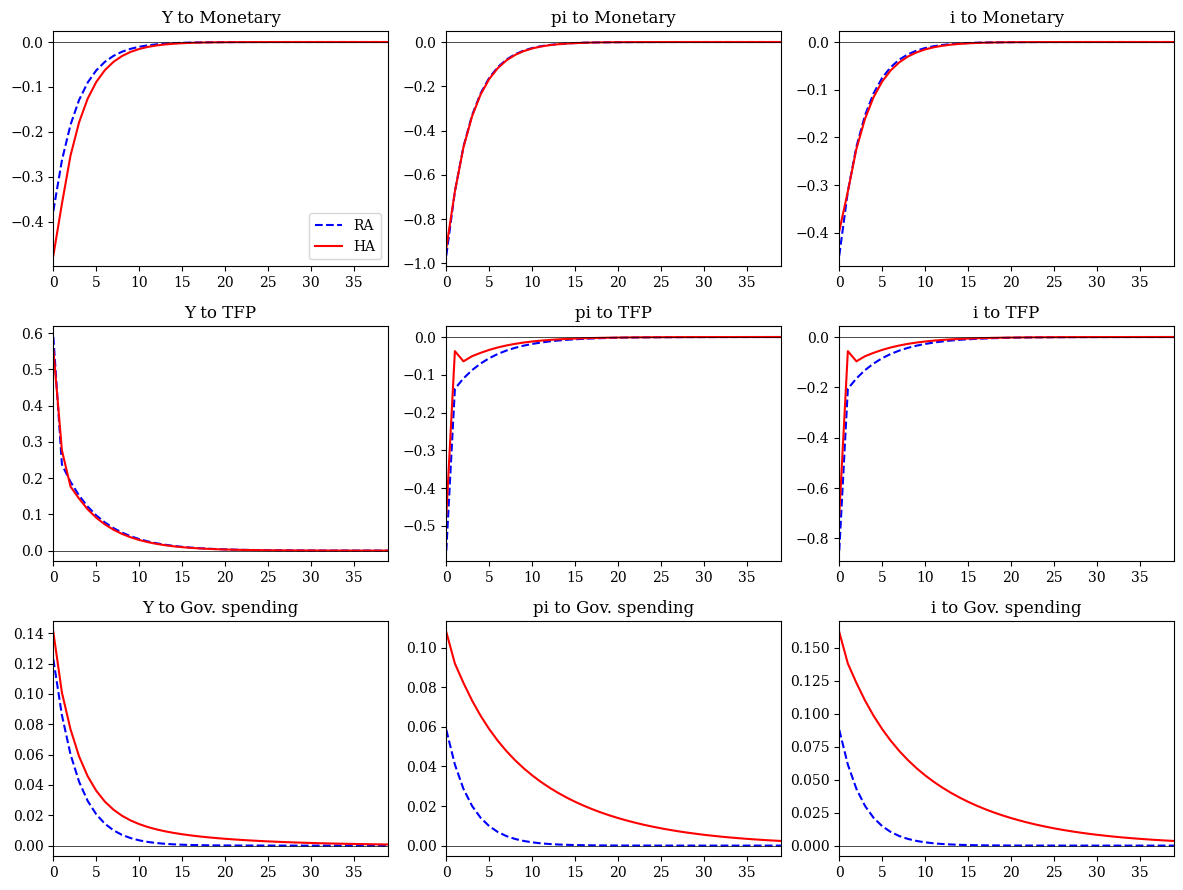

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
plot_vars = ['Y', 'pi', 'i']
shock_labels = {'ishock': 'Monetary', 'X': 'TFP', 'G': 'Gov. spending'}
T_plot = 40

for j, s in enumerate(shock_list):
    for k, v in enumerate(plot_vars):
        ax = axes[j, k]
        ax.plot(irf_ra[s][v][:T_plot], 'b--', label='RA', lw=1.5)
        ax.plot(irf_ha[s][v][:T_plot], 'r-', label='HA', lw=1.5)
        ax.axhline(0, color='k', lw=0.5)
        ax.set_title(f'{v} to {shock_labels[s]}')
        if j == 0 and k == 0: ax.legend()
plt.tight_layout()
plt.savefig('irfs_ra_vs_ha.pdf', bbox_inches='tight')
plt.show()

---
## 5. Estimation Infrastructure

**Likelihood pipeline** (refs: Macro Bible eqs. `ssj_exog_ma`, `ssj_ma_relation`, `ssj_loglikelihood`):
1. Extract shock params $\to$ MA coefficients $M_s^Z = \sigma \rho^s$
2. $M^{X|Z} = G^{X,Z} M^Z$ (GE Jacobian times exogenous MA)
3. Autocovariances from MA representation
4. Gaussian log-likelihood

In [15]:
@njit
def arma_irf(ar_coeff, ma_coeff, T):
    x = np.empty((T,))
    n_ar, n_ma = ar_coeff.size, ma_coeff.size
    for t in range(T):
        if t == 0:
            x[t] = 1
        else:
            s = 0.0
            for i in range(min(n_ar, t)):
                s += ar_coeff[i] * x[t-1-i]
            ma = ma_coeff[t-1] if 0 < t <= n_ma else 0.0
            x[t] = s + ma
    return x

def get_shocks_arma(x, shock_series):
    ix, ish = 0, 0
    sigmas = np.zeros(len(shock_series))
    arcoefs = np.zeros(len(shock_series))
    macoefs = np.zeros(len(shock_series))
    for _, order in shock_series:
        sigmas[ish] = x[ix]; ix += 1
        if order >= 1: arcoefs[ish] = x[ix]; ix += 1
        if order >= 2: macoefs[ish] = x[ix]; ix += 1
        ish += 1
    return sigmas, arcoefs, macoefs

def step1_est(G, arcoefs, macoefs, shock_series, outputs, T, T_irf, n_se, n_sh):
    As = np.empty((T_irf, n_se, n_sh))
    for i_sh in range(n_sh):
        shock_path = arma_irf(np.array([arcoefs[i_sh]]), np.array([macoefs[i_sh]]), T)
        sname = shock_series[i_sh][0]
        for i_se in range(n_se):
            As[:, i_se, i_sh] = (G[outputs[i_se]][sname] @ shock_path)[:T_irf]
    return As

In [16]:
def log_priors(x, priors_list):
    lp = 0.0
    for n in range(len(x)):
        dist, mu, sig = priors_list[n]
        if dist == 'Uniform':
            if x[n] < mu or x[n] > sig: return -np.inf
            lp += -np.log(sig - mu)
        elif dist == 'Invgamma':
            s, v = mu, sig
            if x[n] <= 0: return -np.inf
            lp += (-v-1)*np.log(x[n]) - v*s**2/(2*x[n]**2)
        elif dist == 'Gamma':
            theta = sig**2/mu; k = mu/theta
            if x[n] <= 0: return -np.inf
            lp += (k-1)*np.log(x[n]) - x[n]/theta
        elif dist == 'Normal':
            lp += -0.5*((x[n]-mu)/sig)**2
    return lp

def loglik_f(x, data, outputs, shock_series, priors_list, T, G):
    T_irf = T - 20
    n_se, n_sh = len(outputs), len(shock_series)
    sigmas, arcoefs, macoefs = get_shocks_arma(x, shock_series)
    try:
        As = step1_est(G, arcoefs, macoefs, shock_series, outputs, T, T_irf, n_se, n_sh)
        Sigma = ssj_est.all_covariances(As, sigmas)
        To, O = data.shape
        loglik = ssj_est.log_likelihood(data, Sigma, np.zeros(n_se)) - (To*O*np.log(2*np.pi))/2
    except:
        return -1e10
    lpost = loglik + log_priors(x, priors_list)
    return lpost if np.isfinite(lpost) else -1e10

In [17]:
def hessian_numerical(f, x0, eps=1e-4):
    n = len(x0)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            xpp = x0.copy(); xpp[i] += eps; xpp[j] += eps
            xpm = x0.copy(); xpm[i] += eps; xpm[j] -= eps
            xmp = x0.copy(); xmp[i] -= eps; xmp[j] += eps
            xmm = x0.copy(); xmm[i] -= eps; xmm[j] -= eps
            H[i,j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4*eps**2)
            H[j,i] = H[i,j]
    return H

def estimate(outputs, data, x_guess, shock_series, priors_list, T,
             G=None, params=None, jac_info=None, sd=True, **kwargs):
    if G is not None:
        objective = lambda x: -loglik_f(x, data, outputs, shock_series, priors_list, T, G)
    elif jac_info is not None:
        n_params = len(params)
        last_xp = [np.zeros(n_params)]
        last_G = [{}]
        def objective(x):
            xp = x[-n_params:]
            if not np.allclose(xp, last_xp[0], rtol=1e-12, atol=1e-12):
                ss_new = dict(jac_info['ss'])
                ss_new.update({p: xp[j] for j, p in enumerate(params)})
                from sequence_jacobian.classes.steady_state_dict import SteadyStateDict
                ss_new = SteadyStateDict(ss_new, internals=jac_info['ss'].internals)
                G_new = jac_info['model'].solve_jacobian(
                    ss_new, jac_info['unknowns'], jac_info['targets'],
                    jac_info['exogenous'], outputs=outputs, T=jac_info['T']
                )
                last_xp[0] = xp.copy()
                last_G[0] = G_new
            return -loglik_f(x, data, outputs, shock_series, priors_list, T, last_G[0])
    else:
        raise ValueError('Need G or jac_info')

    result = opt.minimize(objective, x_guess, **kwargs)
    x_sd = np.zeros_like(result.x)
    if sd:
        try:
            H = hessian_numerical(objective, result.x)
            Hinv = np.linalg.inv(H)
            x_sd = np.sqrt(np.maximum(np.diagonal(Hinv), 0))
        except:
            x_sd = np.full_like(result.x, np.nan)
    return result, x_sd

---
## 6. Simulated Data Validation

In [18]:
@njit(parallel=True)
def simul_shock(dX, epsilon):
    dX_flipped = dX[::-1].copy()
    T_irf = len(dX); T_sim = len(epsilon)
    Y = np.empty(T_sim - T_irf + 1)
    for t in prange(T_sim - T_irf + 1):
        Y[t] = np.vdot(dX_flipped, epsilon[t:t+T_irf])
    return Y

def simulate(Gs, inputs, outputs, rhos, sigmas, T, T_simul):
    epsilons = {i: np.random.randn(T_simul + T - 1) for i in inputs}
    sims = {}
    for o in outputs:
        dXs = {i: sigmas[i]*(Gs[o][i] @ rhos[i]**np.arange(T)) for i in inputs}
        sims[o] = sum(simul_shock(dXs[i], epsilons[i]) for i in inputs)
    return sims

In [19]:
# Simulate from known parameters
T_sim = 156
shock_series = [('ishock', 1), ('X', 1), ('G', 1)]
rhos_true = {'ishock': 0.7, 'X': 0.8, 'G': 0.7}
sigs_true = {'ishock': 1.0, 'X': 0.5, 'G': 0.2}
x_true = np.array([1.0, 0.7, 0.5, 0.8, 0.2, 0.7])

np.random.seed(42)
data_sim = simulate(G_ha, exogenous, outputs, rhos_true, sigs_true, T, T_sim)
data_simul = np.column_stack([data_sim[o] for o in outputs])

priors_shocks = [('Uniform',0,2), ('Uniform',0,1), ('Uniform',0,2),
                 ('Uniform',0,1), ('Uniform',0,2), ('Uniform',0,1)]
bounds_shocks = [(0.05,1.5),(0.01,0.99),(0.05,1.5),(0.01,0.99),(0.05,1.5),(0.01,0.99)]
param_names = ['sig_eps', 'rho_eps', 'sig_X', 'rho_X', 'sig_G', 'rho_G']

print("Estimating on simulated data...")
t0 = time.time()
result_sim, sd_sim = estimate(
    outputs, data_simul, 0.9*x_true, shock_series, priors_shocks, T,
    G=G_ha, bounds=bounds_shocks, sd=True,
    method='Nelder-Mead', options={'maxiter': 5000, 'xatol': 1e-5, 'fatol': 1e-5}
)
print(f"Done in {time.time()-t0:.1f}s. Converged: {result_sim.success}")
print(f"\n{'Param':<10} {'True':>8} {'Est':>8} {'SE':>8}")
print("-"*38)
for i, n in enumerate(param_names):
    print(f"{n:<10} {x_true[i]:>8.3f} {result_sim.x[i]:>8.3f} {sd_sim[i]:>8.3f}")

Estimating on simulated data...


Done in 7.8s. Converged: True

Param          True      Est       SE
--------------------------------------
sig_eps       1.000    1.019    0.058
rho_eps       0.700    0.682    0.008
sig_X         0.500    0.509    0.029
rho_X         0.800    0.801    0.022
sig_G         0.200    0.193    0.011
rho_G         0.700    0.625    0.057


---
## 7. Estimation on Real Data

### 7.1 Shock Parameters Only (Tier 1)

In [20]:
if USE_REAL_DATA:
    # Wider bounds for real data (quarterly deviations are small)
    bounds_real = [(0.001,5),(0.01,0.99),(0.001,5),(0.01,0.99),(0.001,5),(0.01,0.99)]
    priors_real = [('Invgamma',0.1,2), ('Uniform',0,1), ('Invgamma',0.1,2),
                   ('Uniform',0,1), ('Invgamma',0.1,2), ('Uniform',0,1)]

    results_shocks = {}
    for mname, G_model in [('ra', G_ra), ('ha', G_ha)]:
        print(f"--- {mname.upper()} ---")
        t0 = time.time()
        res, sd = estimate(
            outputs, data_real, np.array([0.1,0.5,0.1,0.5,0.1,0.5]), shock_series, priors_real, T,
            G=G_model, bounds=bounds_real, sd=True,
            method='Nelder-Mead', options={'maxiter': 5000, 'xatol': 1e-5, 'fatol': 1e-5}
        )
        print(f"  {time.time()-t0:.1f}s, logpost={-res.fun:.2f}")
        for i, n in enumerate(param_names):
            print(f"  {n:<10} {res.x[i]:>8.4f} ({sd[i]:.4f})")
        results_shocks[mname] = (res, sd)
        print()

--- RA ---


  4.0s, logpost=1506.15
  sig_eps      0.0125 (0.0007)
  rho_eps      0.3930 (0.0603)
  sig_X        0.0123 (0.0007)
  rho_X        0.9900 (0.0049)
  sig_G        0.0189 (0.0012)
  rho_G        0.9900 (0.0056)

--- HA ---


  4.5s, logpost=1415.97
  sig_eps      0.0122 (0.0007)
  rho_eps      0.5545 (0.0764)
  sig_X        0.0129 (0.0007)
  rho_X        0.9900 (0.0126)
  sig_G        0.0130 (0.0007)
  rho_G        0.9900 (0.0053)



### 7.2 Shock + Model Parameters (Tier 2)

Key insight: $\phi_T$ is **unidentifiable in RA** (Ricardian equivalence) but **identified in HA**.

In [21]:
# Tier 2 is slow (~10-30 min): recomputes GE Jacobian for each model param change.
# Set RUN_TIER2 = True to run interactively.
RUN_TIER2 = False

if USE_REAL_DATA and RUN_TIER2:
    priors_ext = priors_shocks + [('Uniform',0,1), ('Gamma',1.5,0.25), ('Uniform',0,1)]
    bounds_ext = bounds_shocks + [(0.01,0.99), (1.01,3.0), (0.01,0.99)]
    params_est = ['kappa_w', 'phi_pi', 'phi_T']

    jac_info = {'model': model_ha, 'exogenous': exogenous, 'unknowns': unknowns,
                'targets': targets, 'T': T, 'ss': ss_ha}

    x0_ext = np.concatenate([results_shocks['ha'][0].x, [0.2, 1.5, 0.1]])
    print("HA Tier 2 estimation (shock + model params)...")
    t0 = time.time()
    result_ext, sd_ext = estimate(
        outputs, data_real, x0_ext, shock_series, priors_ext, T,
        params=params_est, jac_info=jac_info, sd=True,
        bounds=bounds_ext,
        method='Nelder-Mead', options={'maxiter': 3000, 'xatol': 1e-4, 'fatol': 1e-4}
    )
    print(f"  {time.time()-t0:.1f}s, logpost={-result_ext.fun:.2f}")
    names_ext = param_names + params_est
    for i, n in enumerate(names_ext):
        print(f"  {n:<10} {result_ext.x[i]:>8.4f} ({sd_ext[i]:.4f})")
elif USE_REAL_DATA:
    print("Tier 2 estimation skipped (set RUN_TIER2 = True to run; takes ~10-30 min)")
    result_ext = None

Tier 2 estimation skipped (set RUN_TIER2 = True to run; takes ~10-30 min)


---
## 8. Post-Estimation Diagnostics

### 8.1 IRFs at Posterior Mode

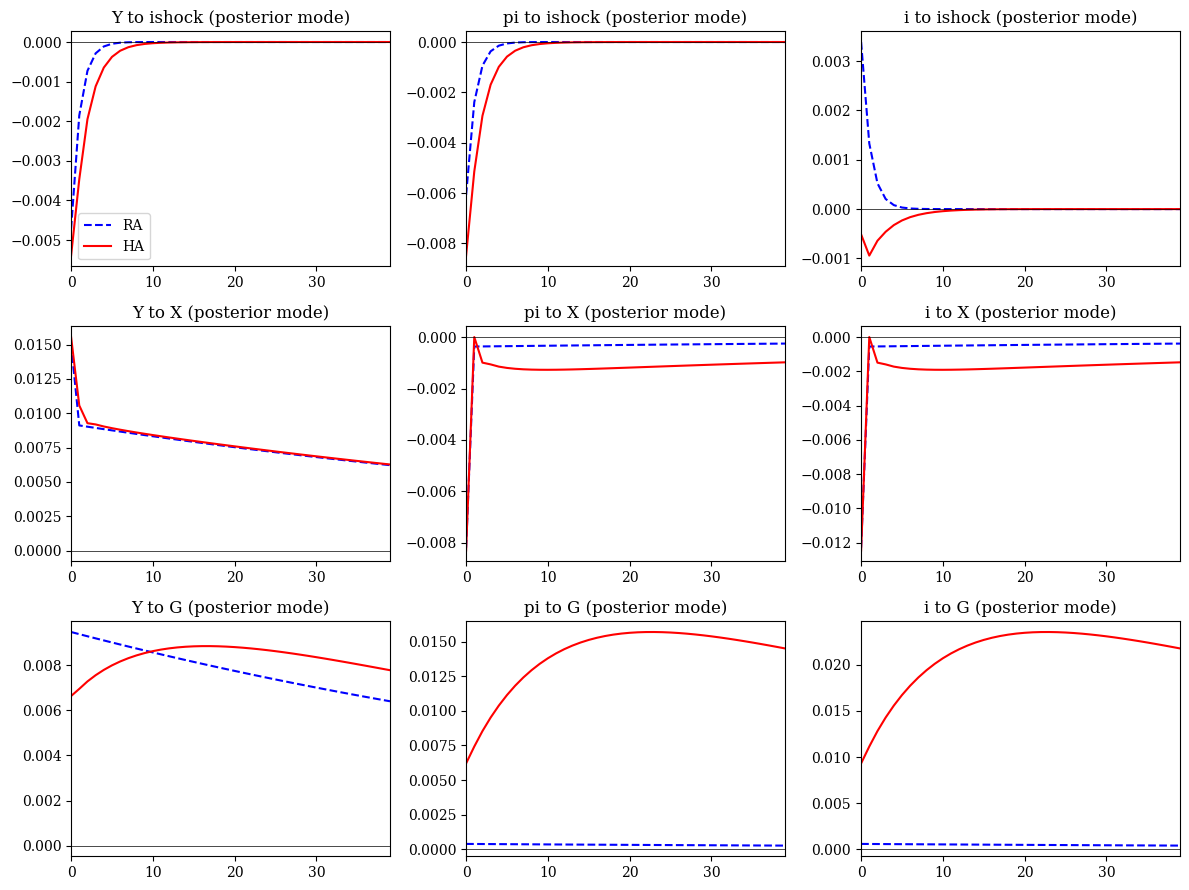

In [22]:
if USE_REAL_DATA:
    def irfs_at_mode(G, x, T, T_plot=40):
        sigmas, arcoefs, _ = get_shocks_arma(x, shock_series)
        irfs = {}
        for i, (sname, _) in enumerate(shock_series):
            sp = sigmas[i] * arcoefs[i]**np.arange(T)
            irfs[sname] = irf_make(G, sp, sname, ['pi','Y','i'], T)
        return irfs

    irfs_ra_m = irfs_at_mode(G_ra, results_shocks['ra'][0].x, T)
    irfs_ha_m = irfs_at_mode(G_ha, results_shocks['ha'][0].x, T)

    fig, axes = plt.subplots(3, 3, figsize=(12, 9))
    for j, s in enumerate(shock_list):
        for k, v in enumerate(['Y', 'pi', 'i']):
            ax = axes[j, k]
            ax.plot(irfs_ra_m[s][v][:40], 'b--', label='RA', lw=1.5)
            ax.plot(irfs_ha_m[s][v][:40], 'r-', label='HA', lw=1.5)
            ax.axhline(0, color='k', lw=0.5)
            ax.set_title(f'{v} to {s} (posterior mode)')
            if j==0 and k==0: ax.legend()
    plt.tight_layout()
    plt.savefig('irfs_posterior_mode.pdf', bbox_inches='tight')
    plt.show()

### 8.2 Historical Shock Decomposition

In [23]:
def construct_stacked_A(As, To, To_out=None, sigma_e=None, sigma_o=None, reshape=True):
    Tm, O, E = As.shape
    if To_out is None: To_out = To
    A_full = np.zeros((To_out, O, To, E))
    for o in range(O):
        for it in range(To):
            iA = it if To <= To_out else it - (To - To_out)
            iAs = -min(iA, 0) if To > To_out else 0
            iA = max(iA, 0)
            sl = min(Tm, To_out - iA)
            for e in range(E):
                A_full[iA:iA+sl, o, it, e] = As[iAs:iAs+sl, o, e]
                if sigma_e is not None: A_full[iA:iA+sl, o, it, e] *= sigma_e[e]
                if sigma_o is not None: A_full[iA:iA+sl, o, it, e] /= sigma_o[o]
    return A_full.reshape((To_out*O, To*E)) if reshape else A_full

def back_out_shocks(As, y, sigma_e=None, preperiods=0):
    To, O = y.shape
    To_pre = To + preperiods
    A_full = construct_stacked_A(As, To=To_pre, To_out=To, sigma_e=sigma_e)
    eps = np.linalg.lstsq(A_full, y.reshape(To*O), rcond=None)[0].reshape((To_pre, As.shape[2]))
    A4 = construct_stacked_A(As, To=To_pre, To_out=To, sigma_e=sigma_e, reshape=False)
    Ds = np.sum(A4 * eps[np.newaxis, np.newaxis, :, :], axis=2)
    return eps[preperiods:], Ds

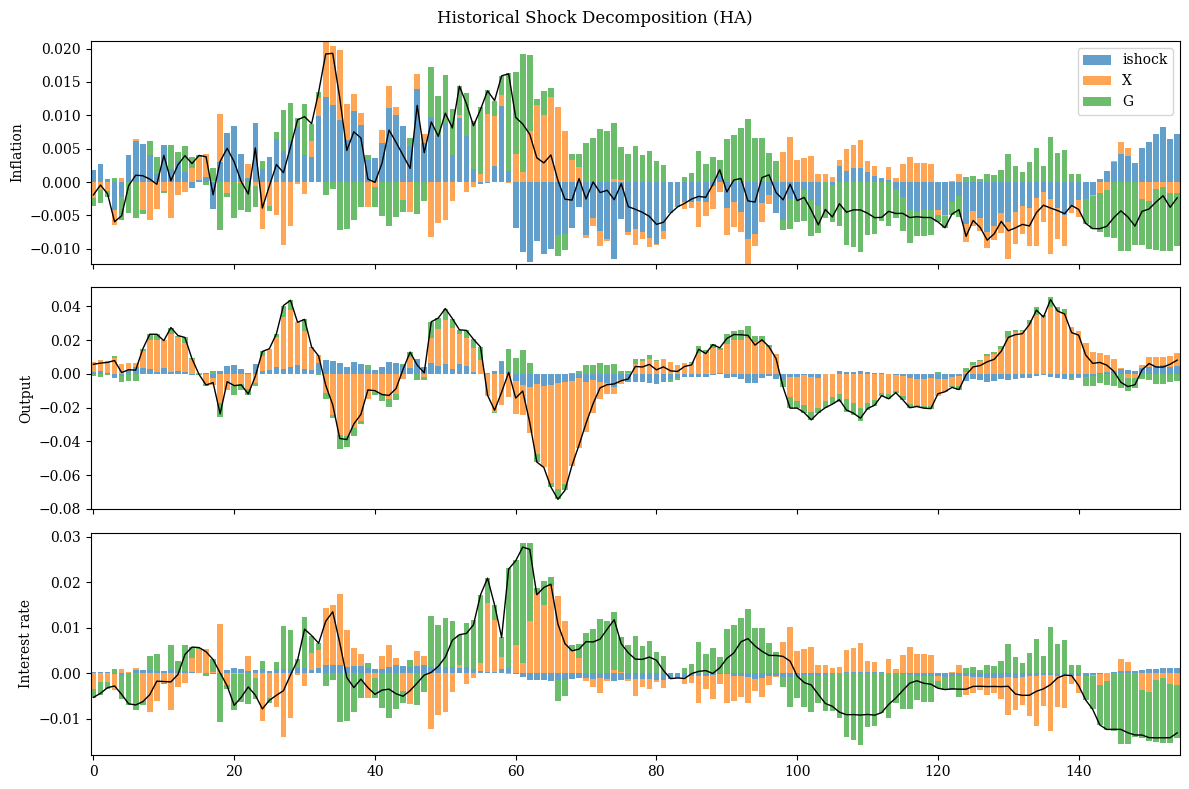

In [24]:
if USE_REAL_DATA:
    x_est = results_shocks['ha'][0].x
    sigmas_est, arcoefs_est, macoefs_est = get_shocks_arma(x_est, shock_series)
    T_irf = T - 20
    As_est = step1_est(G_ha, arcoefs_est, macoefs_est, shock_series, outputs, T, T_irf, 3, 3)
    eps_hat, Ds = back_out_shocks(As_est, data_real, sigma_e=sigmas_est, preperiods=1)

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    To = data_real.shape[0]
    for k, label in enumerate(['Inflation', 'Output', 'Interest rate']):
        ax = axes[k]
        bp, bn = np.zeros(To), np.zeros(To)
        for e in range(3):
            c = Ds[:, k, e]
            ax.bar(range(To), np.maximum(c,0), bottom=bp, color=colors[e], alpha=0.7, label=shock_list[e])
            ax.bar(range(To), np.minimum(c,0), bottom=bn, color=colors[e], alpha=0.7)
            bp += np.maximum(c,0); bn += np.minimum(c,0)
        ax.plot(data_real[:, k], 'k-', lw=1)
        ax.set_ylabel(label)
        if k==0: ax.legend()
    plt.suptitle('Historical Shock Decomposition (HA)')
    plt.tight_layout()
    plt.savefig('historical_decomposition.pdf', bbox_inches='tight')
    plt.show()

### 8.3 Forecast Error Variance Decomposition

FEVD at HA Posterior Mode

Horizon 1Q:
                     MP      TFP      Gov
  pi             40.1%   38.5%   21.4%
  Y               9.2%   76.8%   14.0%
  i               0.1%   64.2%   35.7%

Horizon 4Q:
                     MP      TFP      Gov
  pi             25.1%   16.2%   58.7%
  Y               6.0%   67.8%   26.2%
  i               0.2%   21.6%   78.1%

Horizon 8Q:
                     MP      TFP      Gov
  pi             11.5%    7.9%   80.6%
  Y               3.5%   62.2%   34.4%
  i               0.1%    8.9%   91.0%

Horizon 20Q:
                     MP      TFP      Gov
  pi              3.1%    2.7%   94.2%
  Y               1.5%   53.3%   45.1%
  i               0.0%    2.8%   97.2%


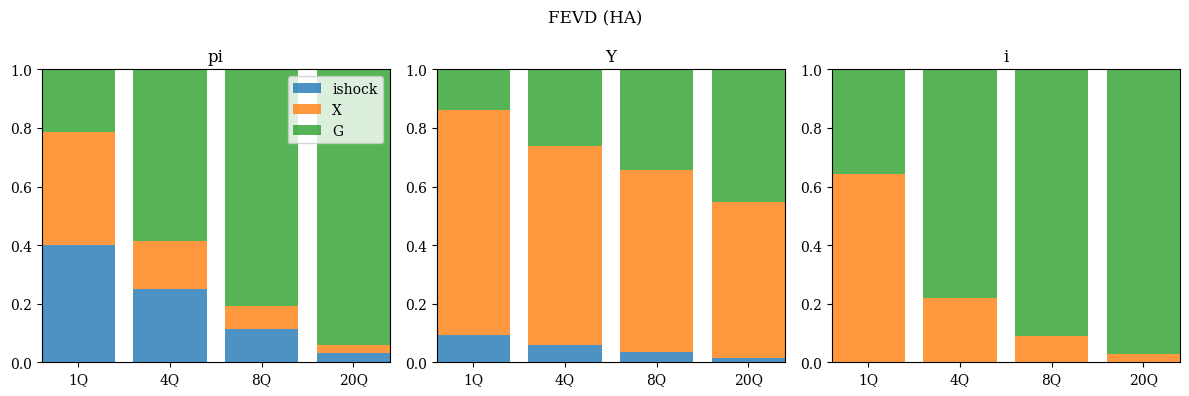

In [25]:
def compute_fevd(As, sigmas, horizons=[1,4,8,20]):
    Tm, O, E = As.shape
    results = {}
    for h in horizons:
        vz = np.zeros((O, E))
        for e in range(E):
            for s in range(min(h, Tm)):
                vz[:, e] += sigmas[e]**2 * As[s, :, e]**2
        results[h] = vz / vz.sum(axis=1, keepdims=True)
    return results

if USE_REAL_DATA:
    fevd = compute_fevd(As_est, sigmas_est)
    print("FEVD at HA Posterior Mode")
    for h in [1, 4, 8, 20]:
        print(f"\nHorizon {h}Q:")
        print(f"  {'':12} {'MP':>8} {'TFP':>8} {'Gov':>8}")
        for k, o in enumerate(outputs):
            print(f"  {o:<12} {fevd[h][k,0]:>7.1%} {fevd[h][k,1]:>7.1%} {fevd[h][k,2]:>7.1%}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for k, o in enumerate(outputs):
        ax = axes[k]
        bot = np.zeros(4)
        for e in range(3):
            v = [fevd[h][k,e] for h in [1,4,8,20]]
            ax.bar(range(4), v, bottom=bot, color=colors[e], label=shock_list[e], alpha=0.8)
            bot += v
        ax.set_xticks(range(4)); ax.set_xticklabels(['1Q','4Q','8Q','20Q'])
        ax.set_title(o); ax.set_ylim(0,1)
        if k==0: ax.legend()
    plt.suptitle('FEVD (HA)')
    plt.tight_layout()
    plt.savefig('fevd_ha.pdf', bbox_inches='tight')
    plt.show()

---
## 9. Summary

- **Model**: Sticky-wage HANK with 3 AR(1) shocks, estimated via SSJ likelihood
- **Key result**: Ricardian equivalence breaks in HA, making $\phi_T$ identifiable
- **hetmacro verification**: EGM and Rouwenhorst match shade-econ to machine precision
- **Pipeline**: GE Jacobian computed once; each posterior evaluation is $\mathcal{O}(T)$ (Tier 1)